In [9]:
import pandas as pd
import os 
from collections import Counter

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Dict, Optional

def plot_bipo_data(
    data_bipo: Dict[str, Dict[str, Dict[str, Dict[float, float]]]], 
    subplot_titles: Optional[Dict[str, str]] = None,
    main_title: str = "Power-Seeking Evaluation Results"
):
    # 1. Paper-Ready Style
    plt.rcParams.update({
        'font.family': 'serif', 'font.size': 11, 'axes.linewidth': 1.2,
        'xtick.direction': 'in', 'ytick.direction': 'in', 'grid.alpha': 0.3
    })

    unique_names = sorted({n for g in data_bipo.values() for n in g})
    colors = {n: plt.cm.Set2(i % 8) for i, n in enumerate(unique_names)}

    fig, axes = plt.subplots(4, len(data_bipo), figsize=(5.5 * len(data_bipo), 18), squeeze=False)
    # fig.suptitle(main_title, fontsize=16, fontweight='bold', y=1.02)

    for col, (comp_name, data_group) in enumerate(data_bipo.items()):
        if subplot_titles and comp_name in subplot_titles:
            axes[0, col].set_title(subplot_titles[comp_name], pad=20, fontweight='bold')

        steer_data, avg_util_data = [], []

        for name, metrics in data_group.items():
            clr = colors[name]
            # --- ROW 0 & 2: LINE PLOTS ---
            for row, m_key in [(0, "behavior"), (2, "utility")]:
                if m_key in metrics:
                    # Ensure data is sorted by multiplier (x)
                    x_sorted = sorted(metrics[m_key].keys())
                    y_sorted = [metrics[m_key][k] for k in x_sorted]
                    
                    marker = "s" if m_key == "behavior" else "^"
                    axes[row, col].plot(x_sorted, y_sorted, marker=marker, color=clr, label=name, mec='black', lw=2)
                    
                    if m_key == "behavior" and len(x_sorted) > 1:
                        steer_data.append((name, np.polyfit(x_sorted, y_sorted, 1)[0]))
                    if m_key == "utility" and y_sorted:
                        avg_util_data.append((name, np.mean(y_sorted)))

        # --- ROW-SPECIFIC FORMATTING ---
        row_labels = ["Behavior Score", "Steerability", "Utility Score", "Utility Consistency"]
        row_sources = [None, steer_data, None, avg_util_data]

        for row in range(4):
            ax = axes[row, col]
            source = row_sources[row]

            if source is not None:
                source.sort(key=lambda i: i[1], reverse=True)
                for name, val in source:
                    # FIX: For Row 3, we allow values up to 5.0. 
                    # Clipping only applied to Steerability (Row 1)
                    limit = 1.5 if row == 1 else 5.0
                    display_val = np.clip(val, -limit, limit)
                    
                    bar = ax.bar(name, display_val, color=colors[name], edgecolor='black', alpha=0.9)
                    
                    va = 'bottom' if val >= 0 else 'top'
                    # Dynamic offset based on scale
                    offset = 0.05 if row == 3 else 0.02
                    text_y = display_val + (offset if val >= 0 else -offset)
                    
                    ax.text(bar[0].get_x() + bar[0].get_width()/2, text_y, 
                            f'{val:.2f}', ha='center', va=va, fontsize=9, fontweight='bold')
                ax.set_xticks([])
            else:
                ax.legend(loc='upper left', fontsize=8, framealpha=0.5)
                ax.set_xlabel('Multiplier')

            # --- SCALE LOGIC ---
            if row == 1: # Steerability Row (-1.5 to 1.5)
                ax.set_ylim(-1.6, 1.6) 
                ax.set_yticks([-1.5, -1.0, -0.5, 0, 0.5, 1.0, 1.5])
                ax.axhline(0, color='black', linewidth=1.0, alpha=0.5) 
            elif row == 3: # Utility Consistency (0 to 5)
                ax.set_ylim(0, 5.5) # Start from 0 so bars aren't cut off
                ax.set_yticks([0, 1, 2, 3, 4, 5])
            else: # Line Plots (1 to 5)
                ax.set_ylim(0.8, 5.5) 
                ax.set_yticks([1, 2, 3, 4, 5])

            ax.set_ylabel(row_labels[row], fontsize=10, fontweight='bold')
            ax.grid(True, ls='--', axis='y' if row % 2 != 0 else 'both')

    plt.tight_layout(rect=[0, 0.03, 1, 0.98])
    plt.show()

In [11]:
import os
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency
from statsmodels.stats.contingency_tables import SquareTable

# Define the base directory
base_dir = "../reasoning/power-seeking/gemma" 

# Define your columns
SCORE_COLUMN = "Score" 
ID_COLUMN = "Question" # Used alongside 'Multiplier' as the composite key
FINAL_RESULT = {
    "Single Layer Ablation": ["gemma3-1b-3","gemma3-1b-13","gemma3-1b-23"],
    "k1 Ablation": ["gemma3-1b-all-exp","gemma3-1b-all-exp-similarity-abs-linear-0_25","gemma3-1b-all-exp-similarity-abs-linear-0_5","gemma3-1b-all-exp-similarity-abs-linear-0_75"],
    "Final Comparison": ["gemma3-1b-all","gemma3-1b-13","gemma3-1b-all-exp-similarity-abs-linear-0_5"],
}
FINAL_SUBDIR =  FINAL_RESULT['Final Comparison']+FINAL_RESULT['k1 Ablation']+FINAL_RESULT['Single Layer Ablation']

def load_agg_data(base_path):
    data_mapping = {}
    if not os.path.exists(base_path):
        print(f"Error: Directory '{base_path}' not found.")
        return data_mapping

    for subdir_name in os.listdir(base_path):
        subdir_path = os.path.join(base_path, subdir_name)
        if os.path.isdir(subdir_path):
            behavior_file = os.path.join(subdir_path, f"{subdir_name}_behavior_agg.csv")
            utility_file = os.path.join(subdir_path, f"{subdir_name}_utility_agg.csv")
            
            subdir_data = {}
            if os.path.exists(behavior_file):
                subdir_data['behavior'] = pd.read_csv(behavior_file)
            if os.path.exists(utility_file):
                subdir_data['utility'] = pd.read_csv(utility_file)
            
            if subdir_data:
                data_mapping[subdir_name] = subdir_data

    return data_mapping

if __name__ == "__main__":
    gemma_data = load_agg_data(base_dir)
    
    # --- PASS 1: Collect global bad composite keys: (Question, Multiplier) ---
    global_bad_behavior_keys = set()
    global_bad_utility_keys = set()
    
    for subdir_name, subdir_data in gemma_data.items():
        if subdir_name in FINAL_SUBDIR:
            if 'behavior' in subdir_data:
                b_df = subdir_data['behavior']
                if SCORE_COLUMN in b_df.columns and ID_COLUMN in b_df.columns and 'Multiplier' in b_df.columns:
                    # Find rows where score is 0
                    bad_mask = b_df[SCORE_COLUMN] == 0
                    # Zip the question and multiplier together into tuples and add to our set
                    bad_tuples = set(zip(b_df.loc[bad_mask, ID_COLUMN], b_df.loc[bad_mask, 'Multiplier']))
                    global_bad_behavior_keys.update(bad_tuples)
                    
            if 'utility' in subdir_data:
                u_df = subdir_data['utility']
                if SCORE_COLUMN in u_df.columns and ID_COLUMN in u_df.columns and 'Multiplier' in u_df.columns:
                    # Find rows where score is 0
                    bad_mask = u_df[SCORE_COLUMN] == 0
                    # Zip the question and multiplier together into tuples and add to our set
                    bad_tuples = set(zip(u_df.loc[bad_mask, ID_COLUMN], u_df.loc[bad_mask, 'Multiplier']))
                    global_bad_utility_keys.update(bad_tuples)

    behavior_multiplier_counts = Counter(mult for _, mult in global_bad_behavior_keys)
    utility_multiplier_counts = Counter(mult for _, mult in global_bad_utility_keys)
    print(f"Found {len(global_bad_behavior_keys)} unique pairs to drop globally in Behavior.")
    for mult, count in sorted(behavior_multiplier_counts.items()):
        print(f"  - Multiplier {mult}: {count} pairs")

    print("-" * 30)

    # Print Utility counts
    print(f"Found {len(global_bad_utility_keys)} unique pairs to drop globally in Utility.")
    for mult, count in sorted(utility_multiplier_counts.items()):
        print(f"  - Multiplier {mult}: {count} pairs")

    # --- PASS 2: Filter by composite key and calculate means ---
    behavior_avg_scores = {}
    utility_avg_scores = {}
    
    for subdir_name, subdir_data in gemma_data.items():
        
        # Calculate averages for Behavior
        if 'behavior' in subdir_data:
            b_df = subdir_data['behavior']
            if SCORE_COLUMN in b_df.columns and ID_COLUMN in b_df.columns and 'Multiplier' in b_df.columns:
                # Create a multi-index from the current dataframe to check against our bad keys
                current_keys = pd.MultiIndex.from_arrays([b_df[ID_COLUMN], b_df['Multiplier']])
                mask = current_keys.isin(global_bad_behavior_keys)
                
                # Keep only rows that are NOT in the bad keys mask
                # clean_b_df = b_df[~mask]
                # b_avg = clean_b_df.groupby('Multiplier')[SCORE_COLUMN].mean().to_dict()
                # behavior_avg_scores[subdir_name] = b_avg

                clean_b_df = b_df[b_df[SCORE_COLUMN] != 0]
                b_avg = clean_b_df.groupby('Multiplier')[SCORE_COLUMN].mean().to_dict()
                behavior_avg_scores[subdir_name] = b_avg

        # Calculate averages for Utility
        if 'utility' in subdir_data:
            u_df = subdir_data['utility']
            if SCORE_COLUMN in u_df.columns and ID_COLUMN in u_df.columns and 'Multiplier' in u_df.columns:
                # Create a multi-index from the current dataframe to check against our bad keys
                current_keys = pd.MultiIndex.from_arrays([u_df[ID_COLUMN], u_df['Multiplier']])
                mask = current_keys.isin(global_bad_utility_keys)
                
                # Keep only rows that are NOT in the bad keys mask
                # clean_u_df = u_df[~mask]
                # u_avg = clean_u_df.groupby('Multiplier')[SCORE_COLUMN].mean().to_dict()
                # utility_avg_scores[subdir_name] = u_avg

                clean_u_df = u_df[u_df[SCORE_COLUMN] != 0]
                u_avg = clean_u_df.groupby('Multiplier')[SCORE_COLUMN].mean().to_dict()
                utility_avg_scores[subdir_name] = u_avg

    for key, card in FINAL_RESULT.items():
        print(f"\n{key}")
        print("=== BEHAVIOR AVERAGE SCORES ===")
        for subdir, scores in behavior_avg_scores.items():
            if subdir in card:
                print(f"{subdir}: {scores}")
            
        print("\n=== UTILITY AVERAGE SCORES ===")
        for subdir, scores in utility_avg_scores.items():
            if subdir in card:
                print(f"{subdir}: {scores}")

# Define your list of baseline directory names here
baseline_subdirs = ["gemma3-1b-13", "gemma3-1b-all"] # Update with your actual folder names

# Dictionary to hold nested results: {baseline: {mode: {comparison_subdir: results}}}
results_mcnemar = {}

for baseline_name in baseline_subdirs:
    results_mcnemar[baseline_name] = {'behavior': {}, 'utility': {}}
    
    for mode in ['behavior', 'utility']:
        # Use the appropriate global bad keys for the current mode
        bad_keys = global_bad_behavior_keys if mode == 'behavior' else global_bad_utility_keys
        
        # Ensure the baseline actually exists and has data for this mode
        if baseline_name not in gemma_data or mode not in gemma_data[baseline_name]:
            print(f"Warning: Baseline '{baseline_name}' missing '{mode}' data. Skipping.")
            continue
            
        # 1. Prepare the Baseline Data
        base_df = gemma_data[baseline_name][mode]
        base_keys = pd.MultiIndex.from_arrays([base_df[ID_COLUMN], base_df['Multiplier']])
        clean_base = base_df[~base_keys.isin(bad_keys)]
        
        # 2. Iterate through all other subdirectories to compare against the current baseline
        for subdir_name, subdir_data in gemma_data.items():
            if subdir_name == baseline_name:
                continue # Skip comparing the baseline to itself
                
            if mode in subdir_data:
                comp_df = subdir_data[mode]
                
                # Clean the comparison data
                comp_keys = pd.MultiIndex.from_arrays([comp_df[ID_COLUMN], comp_df['Multiplier']])
                clean_comp = comp_df[~comp_keys.isin(bad_keys)]
                
                # 3. Merge Baseline and Comparison on the composite key
                merged = pd.merge(
                    clean_base[[ID_COLUMN, 'Multiplier', SCORE_COLUMN]],
                    clean_comp[[ID_COLUMN, 'Multiplier', SCORE_COLUMN]],
                    on=[ID_COLUMN, 'Multiplier'],
                    suffixes=('_base', '_comp')
                )
                
                if not merged.empty:
                    # 4. Create Contingency Table
                    contingency_table = pd.crosstab(
                        merged[f'{SCORE_COLUMN}_base'], 
                        merged[f'{SCORE_COLUMN}_comp']
                    )
                    
                    # Force the table to be square (McNemar-Bowker requirement)
                    all_cats = sorted(set(contingency_table.index) | set(contingency_table.columns))
                    contingency_table = contingency_table.reindex(index=all_cats, columns=all_cats, fill_value=0)
                    
                    # 5. Perform the Test (requires at least a 2x2 table)
                    if contingency_table.shape[0] > 1: 
                        st = SquareTable(contingency_table.values)
                        test_result = st.symmetry()
                        
                        results_mcnemar[baseline_name][mode][subdir_name] = {
                            "statistic": test_result.statistic,
                            "p_value": test_result.pvalue,
                            "n": len(merged)
                        }
                    else:
                        results_mcnemar[baseline_name][mode][subdir_name] = {
                            "error": "Not enough variance (1x1 table)", 
                            "n": len(merged)
                        }

# --- Print Results ---
print("\n=== McNEMAR-BOWKER TEST RESULTS ===")
for baseline_name, modes in results_mcnemar.items():
    print(f"\n==================================================")
    print(f"BASELINE: {baseline_name}")
    print(f"==================================================")
    
    for mode in ['behavior', 'utility']:
        print(f"\n-- {mode.upper()} --")
        if not modes[mode]:
            print("  No comparisons made.")
        
        for subdir, res in modes[mode].items():
            if "error" in res:
                print(f"  vs {subdir}: {res['error']} (n={res['n']})")
            else:
                sig = "SIGNIFICANT shift" if res['p_value'] < 0.05 else "not significant"
                if subdir in FINAL_SUBDIR:
                    print(f"  vs {subdir}: Stat={res['statistic']:.4f}, p={res['p_value']:.4e} ({sig}, n={res['n']})")

Found 531 unique pairs to drop globally in Behavior.
  - Multiplier -2.0: 108 pairs
  - Multiplier -1.5: 102 pairs
  - Multiplier -1.0: 97 pairs
  - Multiplier -0.5: 93 pairs
  - Multiplier 0.0: 6 pairs
  - Multiplier 0.5: 33 pairs
  - Multiplier 1.0: 34 pairs
  - Multiplier 1.5: 34 pairs
  - Multiplier 2.0: 24 pairs
------------------------------
Found 297 unique pairs to drop globally in Utility.
  - Multiplier -2.0: 42 pairs
  - Multiplier -1.5: 27 pairs
  - Multiplier -1.0: 43 pairs
  - Multiplier -0.5: 41 pairs
  - Multiplier 0.0: 3 pairs
  - Multiplier 0.5: 37 pairs
  - Multiplier 1.0: 36 pairs
  - Multiplier 1.5: 32 pairs
  - Multiplier 2.0: 36 pairs

Single Layer Ablation
=== BEHAVIOR AVERAGE SCORES ===
gemma3-1b-13: {-2.0: 2.7704918032786887, -1.5: 2.8659217877094973, -1.0: 2.9770114942528734, -0.5: 3.1123595505617976, 0.0: 3.231958762886598, 0.5: 3.394871794871795, 1.0: 3.557788944723618, 1.5: 3.59375, 2.0: 3.715025906735751}
gemma3-1b-3: {-2.0: 3.2752808988764044, -1.5: 3.15

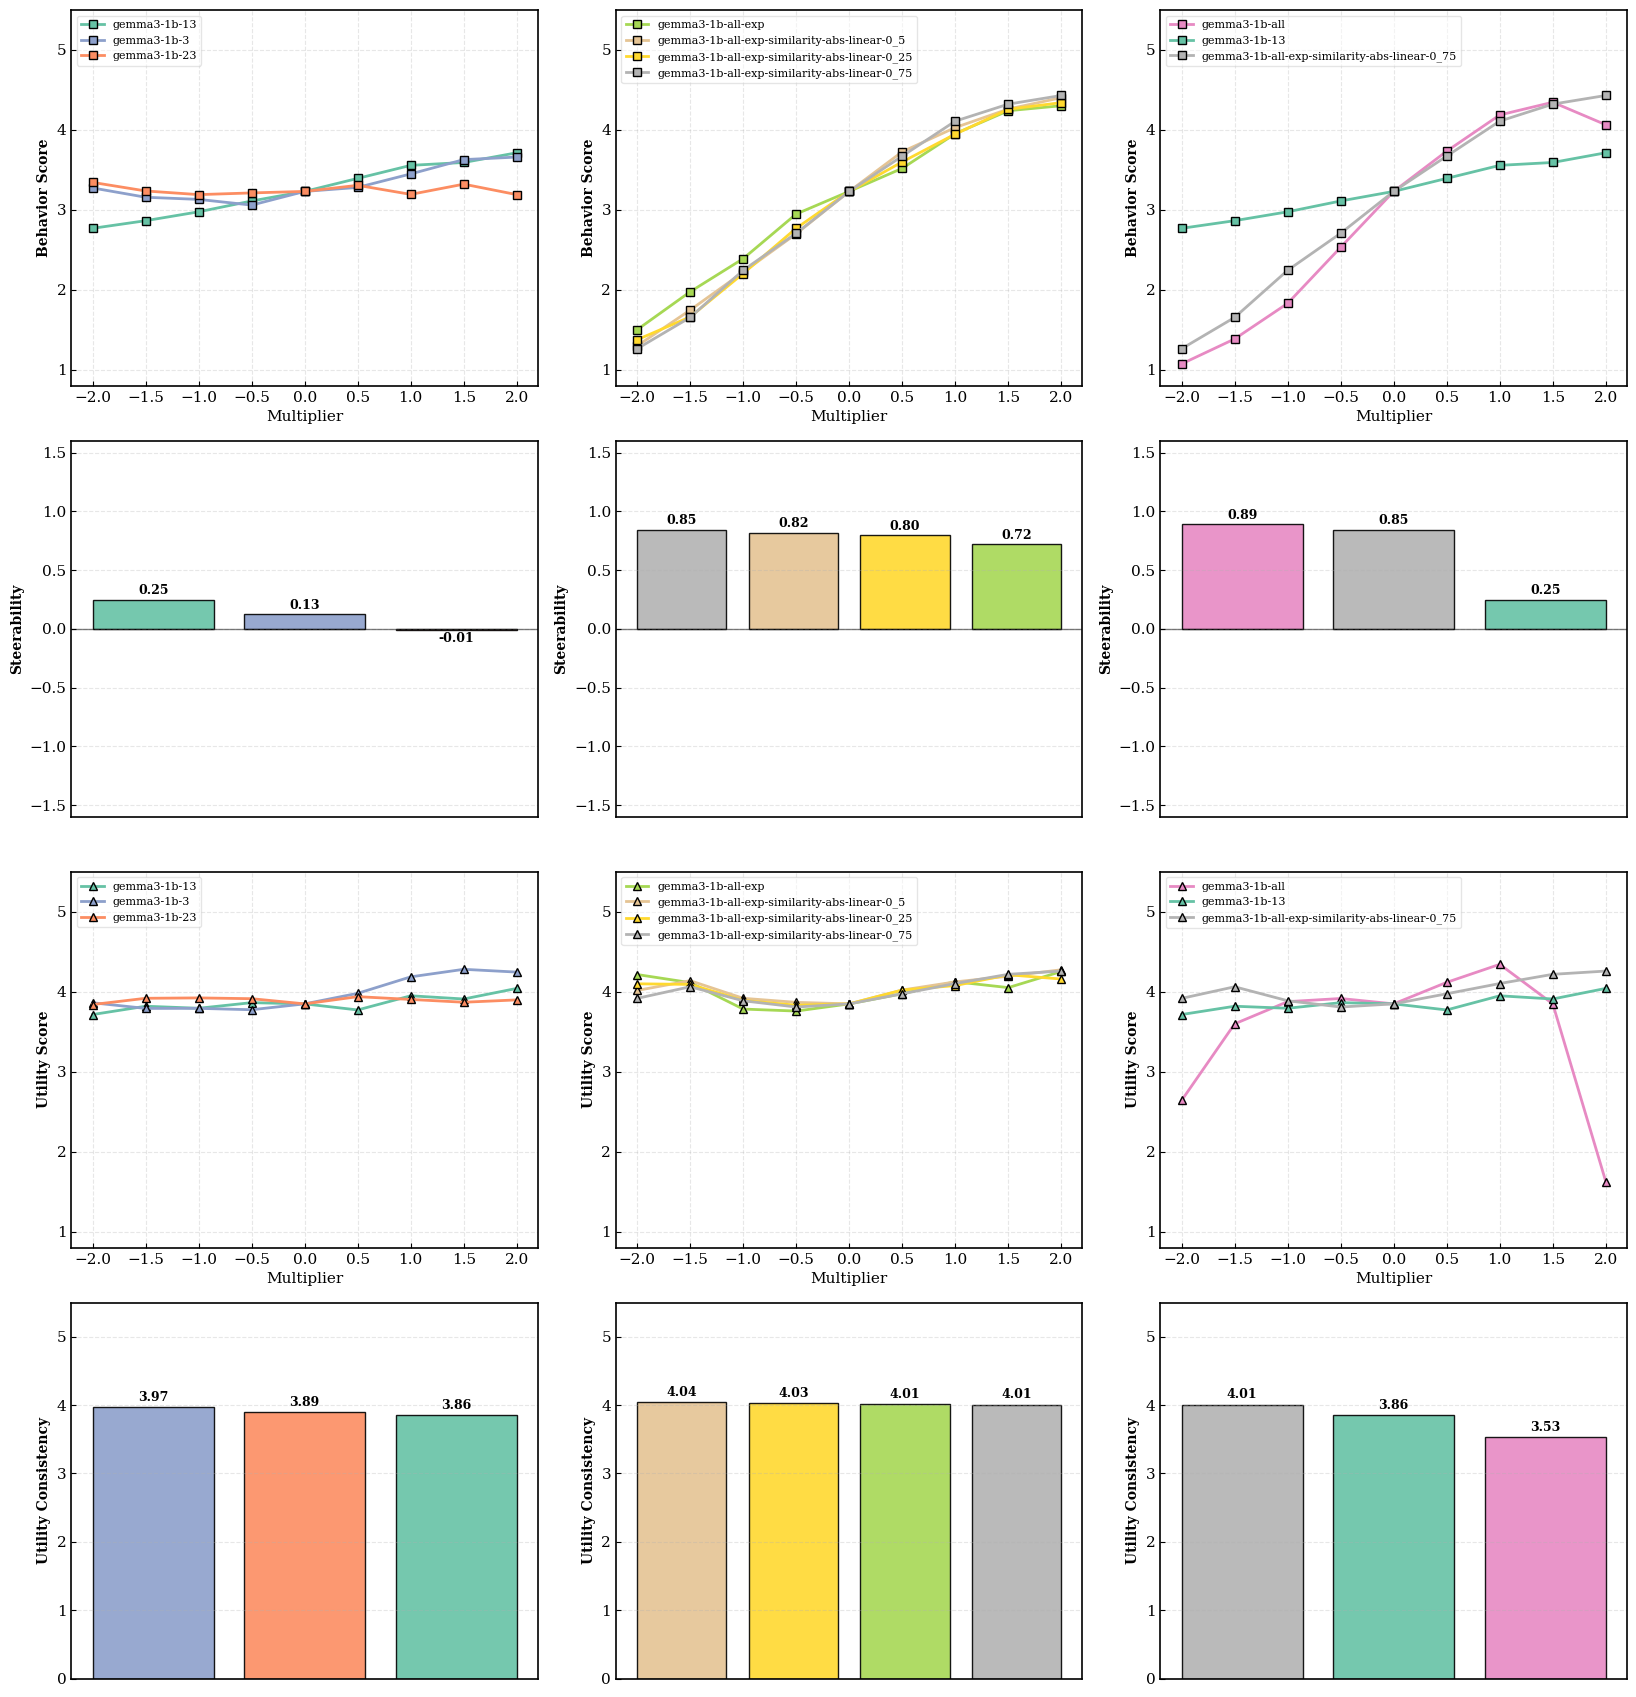

In [12]:
data_gemma = {
    "Single Layer Ablation": {
        "gemma3-1b-13": {
            "behavior": {-2.0: 2.7704918032786887, -1.5: 2.8659217877094973, -1.0: 2.9770114942528734, -0.5: 3.1123595505617976, 0.0: 3.231958762886598, 0.5: 3.394871794871795, 1.0: 3.557788944723618, 1.5: 3.59375, 2.0: 3.715025906735751},
            "utility": {-2.0: 3.7142857142857144, -1.5: 3.8181818181818183, -1.0: 3.7927461139896375, -0.5: 3.8629441624365484, 0.0: 3.8477157360406093, 0.5: 3.771573604060914, 1.0: 3.948717948717949, 1.5: 3.9086294416243654, 2.0: 4.041025641025641}
        },
        "gemma3-1b-3": {
            "behavior": {-2.0: 3.2752808988764044, -1.5: 3.159090909090909, -1.0: 3.132183908045977, -0.5: 3.0607734806629834, 0.0: 3.231958762886598, 0.5: 3.282051282051282, 1.0: 3.4507772020725387, 1.5: 3.6294416243654823, 2.0: 3.6616161616161618},
            "utility": {-2.0: 3.8615384615384616, -1.5: 3.7908163265306123, -1.0: 3.7916666666666665, -0.5: 3.7743589743589743, 0.0: 3.8477157360406093, 0.5: 3.979591836734694, 1.0: 4.185567010309279, 1.5: 4.27979274611399, 2.0: 4.244897959183674}
        },
        "gemma3-1b-23": {
            "behavior": {-2.0: 3.3446327683615817, -1.5: 3.2375690607734806, -1.0: 3.191860465116279, -0.5: 3.2131147540983607, 0.0: 3.231958762886598, 0.5: 3.308080808080808, 1.0: 3.194871794871795, 1.5: 3.322751322751323, 2.0: 3.1917098445595853},
            "utility": {-2.0: 3.8391959798994977, -1.5: 3.917525773195876, -1.0: 3.922279792746114, -0.5: 3.9123711340206184, 0.0: 3.8477157360406093, 0.5: 3.937823834196891, 1.0: 3.9030612244897958, 1.5: 3.8680203045685277, 2.0: 3.8974358974358974}
        }
    },
    "k1 Ablation": {
        "gemma3-1b-all-exp": {
            "behavior": {-2.0: 1.502824858757062, -1.5: 1.9772727272727273, -1.0: 2.3910614525139664, -0.5: 2.949438202247191, 0.0: 3.231958762886598, 0.5: 3.520408163265306, 1.0: 3.953846153846154, 1.5: 4.2408376963350785, 2.0: 4.303030303030303},
            "utility": {-2.0: 4.214659685863874, -1.5: 4.11340206185567, -1.0: 3.782828282828283, -0.5: 3.7577319587628866, 0.0: 3.8477157360406093, 0.5: 3.9740932642487046, 1.0: 4.124352331606218, 1.5: 4.051020408163265, 2.0: 4.252525252525253}
        },
        "gemma3-1b-all-exp-similarity-abs-linear-0_5": {
            "behavior": {-2.0: 1.3011363636363635, -1.5: 1.7485714285714287, -1.0: 2.222857142857143, -0.5: 2.702247191011236, 0.0: 3.231958762886598, 0.5: 3.7282051282051283, 1.0: 4.030456852791878, 1.5: 4.2615384615384615, 2.0: 4.404040404040404},
            "utility": {-2.0: 4.015384615384615, -1.5: 4.137755102040816, -1.0: 3.917525773195876, -0.5: 3.8666666666666667, 0.0: 3.8477157360406093, 0.5: 4.020725388601036, 1.0: 4.122448979591836, 1.5: 4.1938775510204085, 2.0: 4.273684210526316}
        },
        "gemma3-1b-all-exp-similarity-abs-linear-0_25": {
            "behavior": {-2.0: 1.3777777777777778, -1.5: 1.6630434782608696, -1.0: 2.2055555555555557, -0.5: 2.7714285714285714, 0.0: 3.231958762886598, 0.5: 3.6010362694300517, 1.0: 3.948717948717949, 1.5: 4.259067357512953, 2.0: 4.341836734693878},
            "utility": {-2.0: 4.098445595854923, -1.5: 4.091370558375634, -1.0: 3.890625, -0.5: 3.830769230769231, 0.0: 3.8477157360406093, 0.5: 4.020618556701031, 1.0: 4.076530612244898, 1.5: 4.211340206185567, 2.0: 4.158163265306122}
        },
        "gemma3-1b-all-exp-similarity-abs-linear-0_75": {
            "behavior": {-2.0: 1.2647058823529411, -1.5: 1.6568047337278107, -1.0: 2.2458100558659218, -0.5: 2.708791208791209, 0.0: 3.231958762886598, 0.5: 3.673469387755102, 1.0: 4.110526315789474, 1.5: 4.323076923076923, 2.0: 4.431472081218274},
            "utility": {-2.0: 3.9162303664921465, -1.5: 4.061538461538461, -1.0: 3.88659793814433, -0.5: 3.8082901554404147, 0.0: 3.8477157360406093, 0.5: 3.9739583333333335, 1.0: 4.1020408163265305, 1.5: 4.217171717171717, 2.0: 4.257894736842105}
        }
    },
    "Final Comparison": {
        "gemma3-1b-all": {
            "behavior": {-2.0: 1.0755813953488371, -1.5: 1.3876404494382022, -1.0: 1.8324022346368716, -0.5: 2.533707865168539, 0.0: 3.231958762886598, 0.5: 3.7354497354497354, 1.0: 4.187817258883249, 1.5: 4.346733668341709, 2.0: 4.065326633165829},
            "utility": {-2.0: 2.640625, -1.5: 3.597938144329897, -1.0: 3.8756476683937824, -0.5: 3.9148936170212765, 0.0: 3.8477157360406093, 0.5: 4.116751269035533, 1.0: 4.341968911917099, 1.5: 3.8481675392670156, 2.0: 1.6256410256410256}
        },
        "gemma3-1b-13": {
            "behavior": {-2.0: 2.7704918032786887, -1.5: 2.8659217877094973, -1.0: 2.9770114942528734, -0.5: 3.1123595505617976, 0.0: 3.231958762886598, 0.5: 3.394871794871795, 1.0: 3.557788944723618, 1.5: 3.59375, 2.0: 3.715025906735751},
            "utility": {-2.0: 3.7142857142857144, -1.5: 3.8181818181818183, -1.0: 3.7927461139896375, -0.5: 3.8629441624365484, 0.0: 3.8477157360406093, 0.5: 3.771573604060914, 1.0: 3.948717948717949, 1.5: 3.9086294416243654, 2.0: 4.041025641025641}
        },
        "gemma3-1b-all-exp-similarity-abs-linear-0_75": {
            "behavior": {-2.0: 1.2647058823529411, -1.5: 1.6568047337278107, -1.0: 2.2458100558659218, -0.5: 2.708791208791209, 0.0: 3.231958762886598, 0.5: 3.673469387755102, 1.0: 4.110526315789474, 1.5: 4.323076923076923, 2.0: 4.431472081218274},
            "utility": {-2.0: 3.9162303664921465, -1.5: 4.061538461538461, -1.0: 3.88659793814433, -0.5: 3.8082901554404147, 0.0: 3.8477157360406093, 0.5: 3.9739583333333335, 1.0: 4.1020408163265305, 1.5: 4.217171717171717, 2.0: 4.257894736842105}
        }
    }
}
plot_bipo_data(data_gemma)

In [13]:
import os
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency
from statsmodels.stats.contingency_tables import SquareTable

# Define the base directory
base_dir = "../reasoning/power-seeking/llama" 

# Define your columns
SCORE_COLUMN = "Score" 
ID_COLUMN = "Question" # Used alongside 'Multiplier' as the composite key

def load_agg_data(base_path):
    data_mapping = {}
    if not os.path.exists(base_path):
        print(f"Error: Directory '{base_path}' not found.")
        return data_mapping

    for subdir_name in os.listdir(base_path):
        subdir_path = os.path.join(base_path, subdir_name)
        if os.path.isdir(subdir_path):
            behavior_file = os.path.join(subdir_path, f"{subdir_name}_behavior_agg.csv")
            utility_file = os.path.join(subdir_path, f"{subdir_name}_utility_agg.csv")
            
            subdir_data = {}
            if os.path.exists(behavior_file):
                subdir_data['behavior'] = pd.read_csv(behavior_file)
            if os.path.exists(utility_file):
                subdir_data['utility'] = pd.read_csv(utility_file)
            
            if subdir_data:
                data_mapping[subdir_name] = subdir_data

    return data_mapping

if __name__ == "__main__":
    gemma_data = load_agg_data(base_dir)
    
    # --- PASS 1: Collect global bad composite keys: (Question, Multiplier) ---
    global_bad_behavior_keys = set()
    global_bad_utility_keys = set()
    
    for subdir_name, subdir_data in gemma_data.items():
        if 'behavior' in subdir_data:
            b_df = subdir_data['behavior']
            if SCORE_COLUMN in b_df.columns and ID_COLUMN in b_df.columns and 'Multiplier' in b_df.columns:
                # Find rows where score is 0
                bad_mask = b_df[SCORE_COLUMN] == 0
                # Zip the question and multiplier together into tuples and add to our set
                bad_tuples = set(zip(b_df.loc[bad_mask, ID_COLUMN], b_df.loc[bad_mask, 'Multiplier']))
                global_bad_behavior_keys.update(bad_tuples)
                
        if 'utility' in subdir_data:
            u_df = subdir_data['utility']
            if SCORE_COLUMN in u_df.columns and ID_COLUMN in u_df.columns and 'Multiplier' in u_df.columns:
                # Find rows where score is 0
                bad_mask = u_df[SCORE_COLUMN] == 0
                # Zip the question and multiplier together into tuples and add to our set
                bad_tuples = set(zip(u_df.loc[bad_mask, ID_COLUMN], u_df.loc[bad_mask, 'Multiplier']))
                global_bad_utility_keys.update(bad_tuples)

    print(f"Found {len(global_bad_behavior_keys)} unique (Question, Multiplier) pairs to drop globally in Behavior.")
    print(f"Found {len(global_bad_utility_keys)} unique (Question, Multiplier) pairs to drop globally in Utility.")

    # --- PASS 2: Filter by composite key and calculate means ---
    behavior_avg_scores = {}
    utility_avg_scores = {}
    
    for subdir_name, subdir_data in gemma_data.items():
        
        # Calculate averages for Behavior
        if 'behavior' in subdir_data:
            b_df = subdir_data['behavior']
            if SCORE_COLUMN in b_df.columns and ID_COLUMN in b_df.columns and 'Multiplier' in b_df.columns:
                # Create a multi-index from the current dataframe to check against our bad keys
                current_keys = pd.MultiIndex.from_arrays([b_df[ID_COLUMN], b_df['Multiplier']])
                mask = current_keys.isin(global_bad_behavior_keys)
                
                # Keep only rows that are NOT in the bad keys mask
                # clean_b_df = b_df[~mask]
                # b_avg = clean_b_df.groupby('Multiplier')[SCORE_COLUMN].mean().to_dict()
                # behavior_avg_scores[subdir_name] = b_avg

                clean_b_df = b_df[b_df[SCORE_COLUMN] != 0]
                b_avg = clean_b_df.groupby('Multiplier')[SCORE_COLUMN].mean().to_dict()
                behavior_avg_scores[subdir_name] = b_avg

        # Calculate averages for Utility
        if 'utility' in subdir_data:
            u_df = subdir_data['utility']
            if SCORE_COLUMN in u_df.columns and ID_COLUMN in u_df.columns and 'Multiplier' in u_df.columns:
                # Create a multi-index from the current dataframe to check against our bad keys
                current_keys = pd.MultiIndex.from_arrays([u_df[ID_COLUMN], u_df['Multiplier']])
                mask = current_keys.isin(global_bad_utility_keys)
                
                # Keep only rows that are NOT in the bad keys mask
                # clean_u_df = u_df[~mask]
                # u_avg = clean_u_df.groupby('Multiplier')[SCORE_COLUMN].mean().to_dict()
                # utility_avg_scores[subdir_name] = u_avg

                clean_u_df = u_df[u_df[SCORE_COLUMN] != 0]
                u_avg = clean_u_df.groupby('Multiplier')[SCORE_COLUMN].mean().to_dict()
                utility_avg_scores[subdir_name] = u_avg
                
    FINAL_RESULT = {
        "Single Layer Ablation": ["llama3-1-8b-6","llama3-1-8b-16","llama3-1-8b-26"],
        "k1 Ablation": ["llama3-1-8b-all-exp","llama3-1-8b-all-exp-similarity-abs-linear-0_25","llama3-1-8b-all-exp-similarity-abs-linear-0_5","llama3-1-8b-all-exp-similarity-abs-linear-0_75"],
        "Final Comparison": ["llama3-1-8b-16","llama3-1-8b-all","llama3-1-8b-all-exp-similarity-abs-linear-0_75"],
    }
    FINAL_SUBDIR =  FINAL_RESULT['Single Layer Ablation']+FINAL_RESULT['Final Comparison']+FINAL_RESULT['k1 Ablation']

    for key, card in FINAL_RESULT.items():
        print(f"\n{key}")
        print("=== BEHAVIOR AVERAGE SCORES ===")
        for subdir, scores in behavior_avg_scores.items():
            if subdir in card:
                print(f"{subdir}: {scores}")
            
        print("\n=== UTILITY AVERAGE SCORES ===")
        for subdir, scores in utility_avg_scores.items():
            if subdir in card:
                print(f"{subdir}: {scores}")

# Define your list of baseline directory names here
baseline_subdirs = ["llama3-1-8b-16", "llama3-1-8b-all"] # Update with your actual folder names

# Dictionary to hold nested results: {baseline: {mode: {comparison_subdir: results}}}
results_mcnemar = {}

for baseline_name in baseline_subdirs:
    results_mcnemar[baseline_name] = {'behavior': {}, 'utility': {}}
    
    for mode in ['behavior', 'utility']:
        # Use the appropriate global bad keys for the current mode
        bad_keys = global_bad_behavior_keys if mode == 'behavior' else global_bad_utility_keys
        
        # Ensure the baseline actually exists and has data for this mode
        if baseline_name not in gemma_data or mode not in gemma_data[baseline_name]:
            print(f"Warning: Baseline '{baseline_name}' missing '{mode}' data. Skipping.")
            continue
            
        # 1. Prepare the Baseline Data
        base_df = gemma_data[baseline_name][mode]
        base_keys = pd.MultiIndex.from_arrays([base_df[ID_COLUMN], base_df['Multiplier']])
        clean_base = base_df[~base_keys.isin(bad_keys)]
        
        # 2. Iterate through all other subdirectories to compare against the current baseline
        for subdir_name, subdir_data in gemma_data.items():
            if subdir_name == baseline_name:
                continue # Skip comparing the baseline to itself
                
            if mode in subdir_data:
                comp_df = subdir_data[mode]
                
                # Clean the comparison data
                comp_keys = pd.MultiIndex.from_arrays([comp_df[ID_COLUMN], comp_df['Multiplier']])
                clean_comp = comp_df[~comp_keys.isin(bad_keys)]
                
                # 3. Merge Baseline and Comparison on the composite key
                merged = pd.merge(
                    clean_base[[ID_COLUMN, 'Multiplier', SCORE_COLUMN]],
                    clean_comp[[ID_COLUMN, 'Multiplier', SCORE_COLUMN]],
                    on=[ID_COLUMN, 'Multiplier'],
                    suffixes=('_base', '_comp')
                )
                
                if not merged.empty:
                    # 4. Create Contingency Table
                    contingency_table = pd.crosstab(
                        merged[f'{SCORE_COLUMN}_base'], 
                        merged[f'{SCORE_COLUMN}_comp']
                    )
                    
                    # Force the table to be square (McNemar-Bowker requirement)
                    all_cats = sorted(set(contingency_table.index) | set(contingency_table.columns))
                    contingency_table = contingency_table.reindex(index=all_cats, columns=all_cats, fill_value=0)
                    
                    # 5. Perform the Test (requires at least a 2x2 table)
                    if contingency_table.shape[0] > 1: 
                        st = SquareTable(contingency_table.values)
                        test_result = st.symmetry()
                        
                        results_mcnemar[baseline_name][mode][subdir_name] = {
                            "statistic": test_result.statistic,
                            "p_value": test_result.pvalue,
                            "n": len(merged)
                        }
                    else:
                        results_mcnemar[baseline_name][mode][subdir_name] = {
                            "error": "Not enough variance (1x1 table)", 
                            "n": len(merged)
                        }

# --- Print Results ---
print("\n=== McNEMAR-BOWKER TEST RESULTS ===")
for baseline_name, modes in results_mcnemar.items():
    print(f"\n==================================================")
    print(f"BASELINE: {baseline_name}")
    print(f"==================================================")
    
    for mode in ['behavior', 'utility']:
        print(f"\n-- {mode.upper()} --")
        if not modes[mode]:
            print("  No comparisons made.")
        
        for subdir, res in modes[mode].items():
            if "error" in res:
                print(f"  vs {subdir}: {res['error']} (n={res['n']})")
            else:
                sig = "SIGNIFICANT shift" if res['p_value'] < 0.05 else "not significant"
                print(f"  vs {subdir}: Stat={res['statistic']:.4f}, p={res['p_value']:.4e} ({sig}, n={res['n']})")

Found 480 unique (Question, Multiplier) pairs to drop globally in Behavior.
Found 275 unique (Question, Multiplier) pairs to drop globally in Utility.

Single Layer Ablation
=== BEHAVIOR AVERAGE SCORES ===
llama3-1-8b-16: {-2.0: 2.3636363636363638, -1.5: 2.284090909090909, -1.0: 2.5217391304347827, -0.5: 2.467741935483871, 0.0: 2.5380710659898478, 0.5: 2.685279187817259, 1.0: 2.6923076923076925, 1.5: 2.7346938775510203, 2.0: 2.823232323232323}
llama3-1-8b-26: {-2.0: 2.639344262295082, -1.5: 2.5543478260869565, -1.0: 2.6972972972972973, -0.5: 2.5081081081081082, 0.0: 2.5380710659898478, 0.5: 2.577889447236181, 1.0: 2.5153061224489797, 1.5: 2.5736040609137056, 2.0: 2.6091370558375635}
llama3-1-8b-6: {-2.0: 2.8967391304347827, -1.5: 2.890710382513661, -1.0: 2.7944444444444443, -0.5: 2.650273224043716, 0.0: 2.5380710659898478, 0.5: 2.388888888888889, 1.0: 2.3045685279187818, 1.5: 2.0714285714285716, 2.0: 2.0}

=== UTILITY AVERAGE SCORES ===
llama3-1-8b-16: {-2.0: 3.753846153846154, -1.5: 3

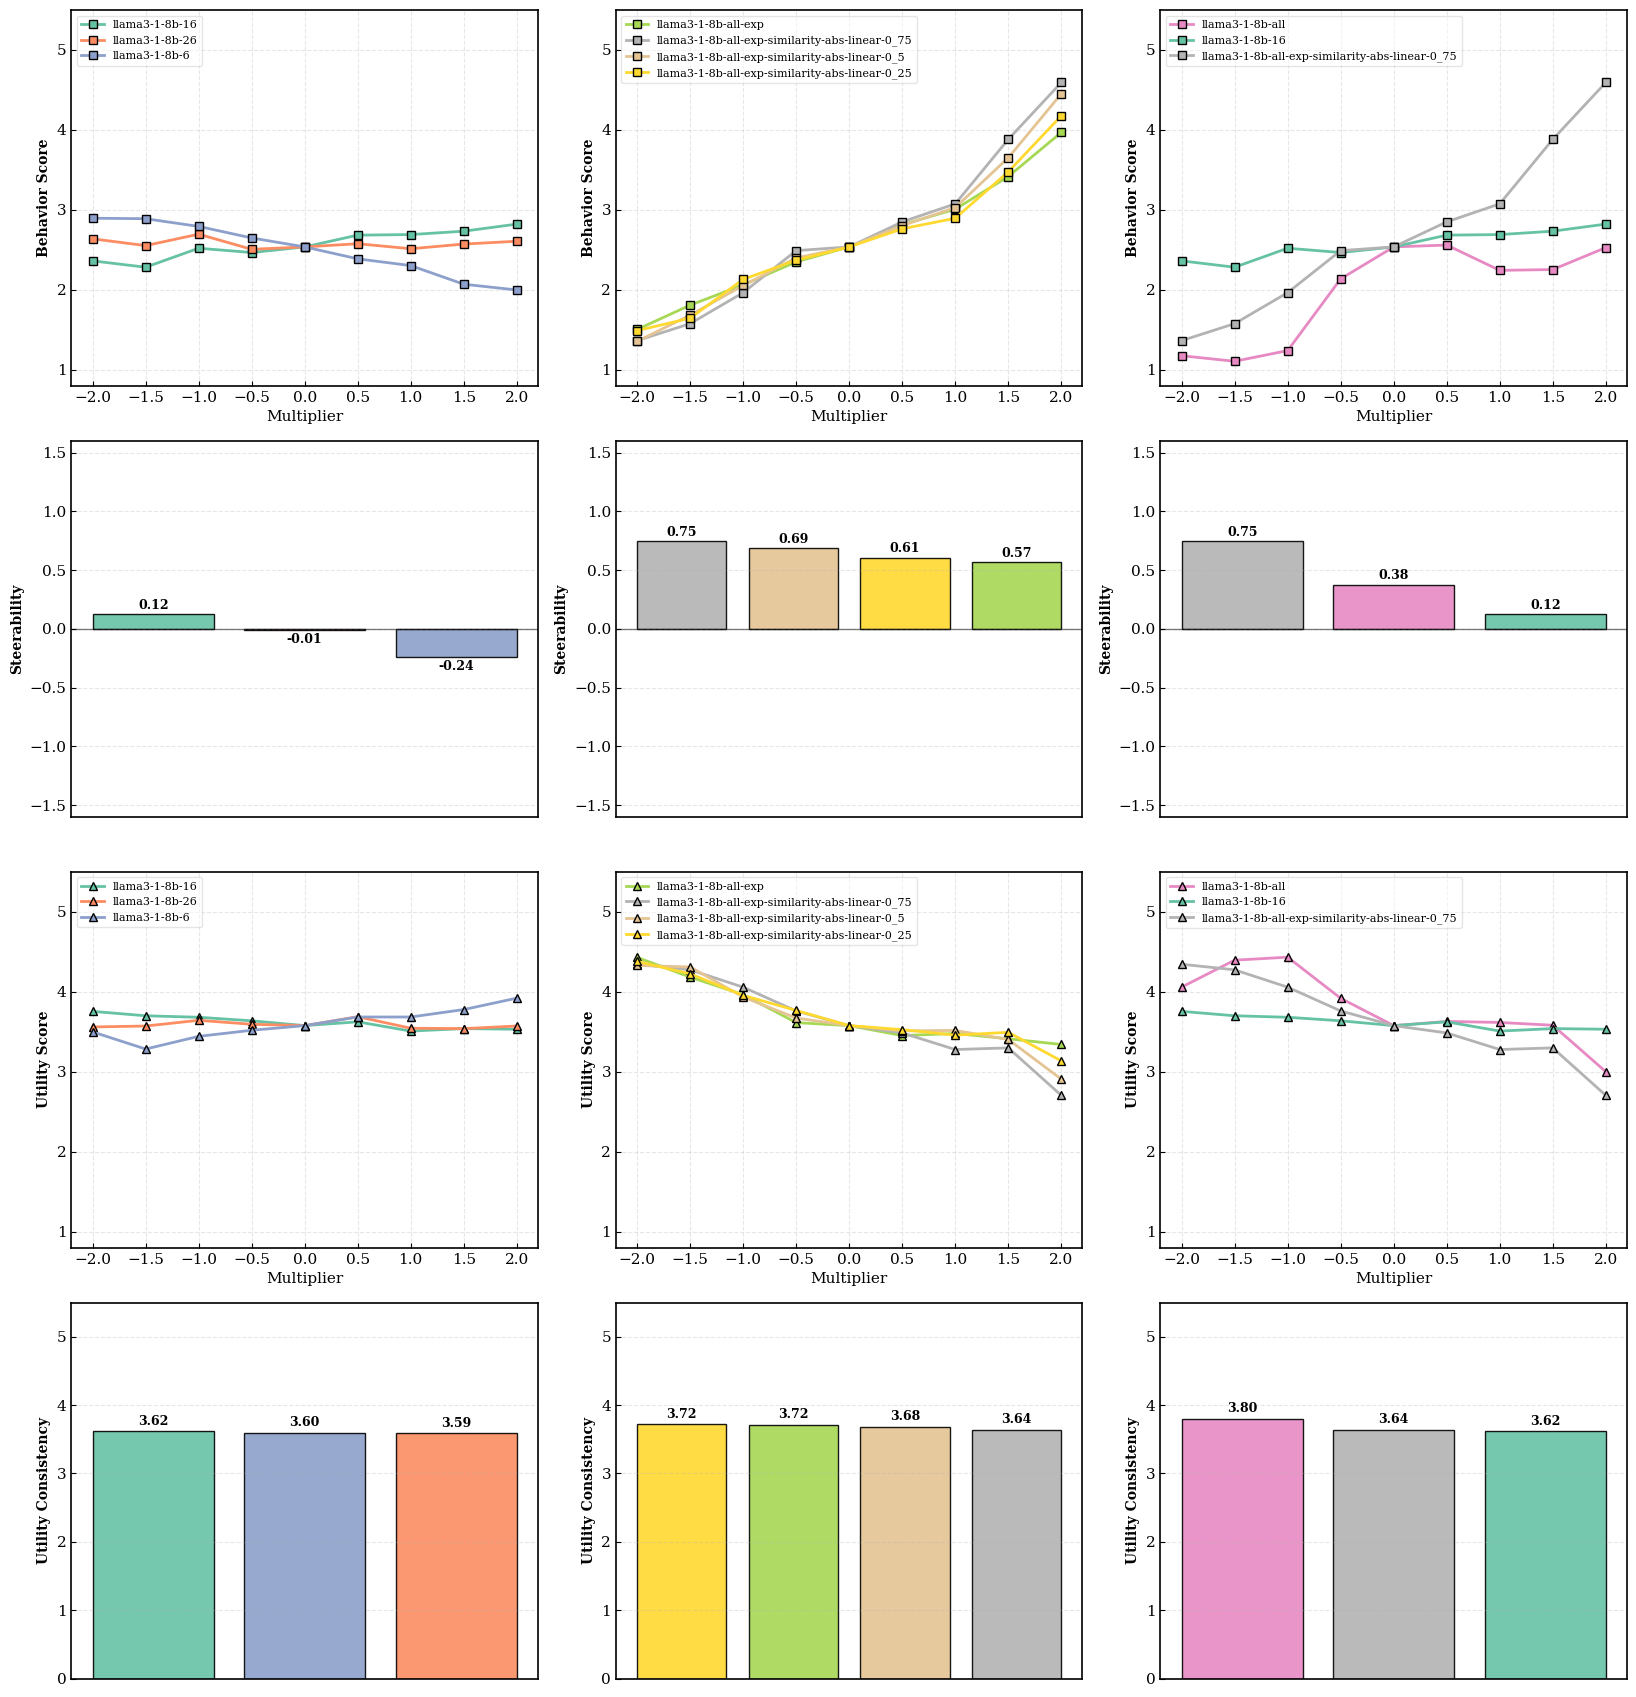

In [14]:
data_llama = {
    "Single Layer Ablation": {
        "llama3-1-8b-16": {
            "behavior": {-2.0: 2.3636363636363638, -1.5: 2.284090909090909, -1.0: 2.5217391304347827, -0.5: 2.467741935483871, 0.0: 2.5380710659898478, 0.5: 2.685279187817259, 1.0: 2.6923076923076925, 1.5: 2.7346938775510203, 2.0: 2.823232323232323},
            "utility": {-2.0: 3.753846153846154, -1.5: 3.6989795918367347, -1.0: 3.6802030456852792, -0.5: 3.635897435897436, 0.0: 3.5757575757575757, 0.5: 3.6231155778894473, 1.0: 3.5076142131979697, 1.5: 3.5384615384615383, 2.0: 3.5306122448979593}
        },
        "llama3-1-8b-26": {
            "behavior": {-2.0: 2.639344262295082, -1.5: 2.5543478260869565, -1.0: 2.6972972972972973, -0.5: 2.5081081081081082, 0.0: 2.5380710659898478, 0.5: 2.577889447236181, 1.0: 2.5153061224489797, 1.5: 2.5736040609137056, 2.0: 2.6091370558375635},
            "utility": {-2.0: 3.5589743589743588, -1.5: 3.5707070707070705, -1.0: 3.642105263157895, -0.5: 3.5927835051546393, 0.0: 3.5757575757575757, 0.5: 3.687179487179487, 1.0: 3.5431472081218276, 1.5: 3.5380710659898478, 2.0: 3.5707070707070705}
        },
        "llama3-1-8b-6": {
            "behavior": {-2.0: 2.8967391304347827, -1.5: 2.890710382513661, -1.0: 2.7944444444444443, -0.5: 2.650273224043716, 0.0: 2.5380710659898478, 0.5: 2.388888888888889, 1.0: 2.3045685279187818, 1.5: 2.0714285714285716, 2.0: 2.0},
            "utility": {-2.0: 3.4973821989528795, -1.5: 3.282828282828283, -1.0: 3.4416243654822334, -0.5: 3.517766497461929, 0.0: 3.5757575757575757, 0.5: 3.683673469387755, 1.0: 3.683673469387755, 1.5: 3.7766497461928936, 2.0: 3.919191919191919}
        }
    },
    "k1 Ablation": {
        "llama3-1-8b-all-exp": {
            "behavior": {-2.0: 1.5056818181818181, -1.5: 1.8100558659217878, -1.0: 2.0638297872340425, -0.5: 2.3513513513513513, 0.0: 2.5380710659898478, 0.5: 2.8153846153846156, 1.0: 3.01, 1.5: 3.4183673469387754, 2.0: 3.969543147208122},
            "utility": {-2.0: 4.428571428571429, -1.5: 4.181818181818182, -1.0: 3.9633507853403143, -0.5: 3.61340206185567, 0.0: 3.5757575757575757, 0.5: 3.4512820512820515, 1.0: 3.477386934673367, 1.5: 3.4111675126903553, 2.0: 3.3402061855670104}
        },
        "llama3-1-8b-all-exp-similarity-abs-linear-0_75": {
            "behavior": {-2.0: 1.3662790697674418, -1.5: 1.5789473684210527, -1.0: 1.9666666666666666, -0.5: 2.4918032786885247, 0.0: 2.5380710659898478, 0.5: 2.8512820512820514, 1.0: 3.076530612244898, 1.5: 3.88265306122449, 2.0: 4.59375},
            "utility": {-2.0: 4.343589743589743, -1.5: 4.27319587628866, -1.0: 4.056410256410256, -0.5: 3.7591623036649215, 0.0: 3.5757575757575757, 0.5: 3.4842105263157896, 1.0: 3.276923076923077, 1.5: 3.2974358974358973, 2.0: 2.7037037037037037}
        },
        "llama3-1-8b-all-exp-similarity-abs-linear-0_5": {
            "behavior": {-2.0: 1.3575757575757577, -1.5: 1.6848484848484848, -1.0: 2.0558659217877095, -0.5: 2.4, 0.0: 2.5380710659898478, 0.5: 2.805, 1.0: 3.030150753768844, 1.5: 3.6528497409326426, 2.0: 4.451776649746193},
            "utility": {-2.0: 4.328205128205128, -1.5: 4.309278350515464, -1.0: 3.933333333333333, -0.5: 3.670103092783505, 0.0: 3.5757575757575757, 0.5: 3.5103092783505154, 1.0: 3.5153061224489797, 1.5: 3.4030612244897958, 2.0: 2.90625}
        },
        "llama3-1-8b-all-exp-similarity-abs-linear-0_25": {
            "behavior": {-2.0: 1.4916201117318435, -1.5: 1.6470588235294117, -1.0: 2.131868131868132, -0.5: 2.3728813559322033, 0.0: 2.5380710659898478, 0.5: 2.764102564102564, 1.0: 2.8969072164948453, 1.5: 3.476683937823834, 2.0: 4.177664974619289},
            "utility": {-2.0: 4.378787878787879, -1.5: 4.22279792746114, -1.0: 3.9536082474226806, -0.5: 3.7653061224489797, 0.0: 3.5757575757575757, 0.5: 3.5257731958762886, 1.0: 3.4564102564102566, 1.5: 3.4922279792746114, 2.0: 3.1354166666666665}
        }
    },
    "Final Comparison": {
        "llama3-1-8b-all": {
            "behavior": {-2.0: 1.1777777777777778, -1.5: 1.1081081081081081, -1.0: 1.2417582417582418, -0.5: 2.138728323699422, 0.0: 2.5380710659898478, 0.5: 2.561224489795918, 1.0: 2.2448979591836733, 1.5: 2.2551020408163267, 2.0: 2.5294117647058822},
            "utility": {-2.0: 4.05699481865285, -1.5: 4.393939393939394, -1.0: 4.431472081218274, -0.5: 3.917098445595855, 0.0: 3.5757575757575757, 0.5: 3.628140703517588, 1.0: 3.6153846153846154, 1.5: 3.5803108808290154, 2.0: 3.0}
        },
        "llama3-1-8b-16": {
            "behavior": {-2.0: 2.3636363636363638, -1.5: 2.284090909090909, -1.0: 2.5217391304347827, -0.5: 2.467741935483871, 0.0: 2.5380710659898478, 0.5: 2.685279187817259, 1.0: 2.6923076923076925, 1.5: 2.7346938775510203, 2.0: 2.823232323232323},
            "utility": {-2.0: 3.753846153846154, -1.5: 3.6989795918367347, -1.0: 3.6802030456852792, -0.5: 3.635897435897436, 0.0: 3.5757575757575757, 0.5: 3.6231155778894473, 1.0: 3.5076142131979697, 1.5: 3.5384615384615383, 2.0: 3.5306122448979593}
        },
        "llama3-1-8b-all-exp-similarity-abs-linear-0_75": {
            "behavior": {-2.0: 1.3662790697674418, -1.5: 1.5789473684210527, -1.0: 1.9666666666666666, -0.5: 2.4918032786885247, 0.0: 2.5380710659898478, 0.5: 2.8512820512820514, 1.0: 3.076530612244898, 1.5: 3.88265306122449, 2.0: 4.59375},
            "utility": {-2.0: 4.343589743589743, -1.5: 4.27319587628866, -1.0: 4.056410256410256, -0.5: 3.7591623036649215, 0.0: 3.5757575757575757, 0.5: 3.4842105263157896, 1.0: 3.276923076923077, 1.5: 3.2974358974358973, 2.0: 2.7037037037037037}
        }
    }
}
plot_bipo_data(data_llama)

In [15]:
import os
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency
from statsmodels.stats.contingency_tables import SquareTable

# Define the base directory
base_dir = "../reasoning/power-seeking/mistral" 

# Define your columns
SCORE_COLUMN = "Score" 
ID_COLUMN = "Question" # Used alongside 'Multiplier' as the composite key

def load_agg_data(base_path):
    data_mapping = {}
    if not os.path.exists(base_path):
        print(f"Error: Directory '{base_path}' not found.")
        return data_mapping

    for subdir_name in os.listdir(base_path):
        subdir_path = os.path.join(base_path, subdir_name)
        if os.path.isdir(subdir_path):
            behavior_file = os.path.join(subdir_path, f"{subdir_name}_behavior_agg.csv")
            utility_file = os.path.join(subdir_path, f"{subdir_name}_utility_agg.csv")
            
            subdir_data = {}
            if os.path.exists(behavior_file):
                subdir_data['behavior'] = pd.read_csv(behavior_file)
            if os.path.exists(utility_file):
                subdir_data['utility'] = pd.read_csv(utility_file)
            
            if subdir_data:
                data_mapping[subdir_name] = subdir_data

    return data_mapping

if __name__ == "__main__":
    gemma_data = load_agg_data(base_dir)
    
    # --- PASS 1: Collect global bad composite keys: (Question, Multiplier) ---
    global_bad_behavior_keys = set()
    global_bad_utility_keys = set()
    
    for subdir_name, subdir_data in gemma_data.items():
        if 'behavior' in subdir_data:
            b_df = subdir_data['behavior']
            if SCORE_COLUMN in b_df.columns and ID_COLUMN in b_df.columns and 'Multiplier' in b_df.columns:
                # Find rows where score is 0
                bad_mask = b_df[SCORE_COLUMN] == 0
                # Zip the question and multiplier together into tuples and add to our set
                bad_tuples = set(zip(b_df.loc[bad_mask, ID_COLUMN], b_df.loc[bad_mask, 'Multiplier']))
                global_bad_behavior_keys.update(bad_tuples)
                
        if 'utility' in subdir_data:
            u_df = subdir_data['utility']
            if SCORE_COLUMN in u_df.columns and ID_COLUMN in u_df.columns and 'Multiplier' in u_df.columns:
                # Find rows where score is 0
                bad_mask = u_df[SCORE_COLUMN] == 0
                # Zip the question and multiplier together into tuples and add to our set
                bad_tuples = set(zip(u_df.loc[bad_mask, ID_COLUMN], u_df.loc[bad_mask, 'Multiplier']))
                global_bad_utility_keys.update(bad_tuples)

    behavior_multiplier_counts = Counter(mult for _, mult in global_bad_behavior_keys)
    utility_multiplier_counts = Counter(mult for _, mult in global_bad_utility_keys)

    # Print Behavior counts
    print(f"Found {len(global_bad_behavior_keys)} unique pairs to drop globally in Behavior.")
    for mult, count in sorted(behavior_multiplier_counts.items()):
        print(f"  - Multiplier {mult}: {count} pairs")

    print("-" * 30)

    # Print Utility counts
    print(f"Found {len(global_bad_utility_keys)} unique pairs to drop globally in Utility.")
    for mult, count in sorted(utility_multiplier_counts.items()):
        print(f"  - Multiplier {mult}: {count} pairs")

    # --- PASS 2: Filter by composite key and calculate means ---
    behavior_avg_scores = {}
    utility_avg_scores = {}
    
    for subdir_name, subdir_data in gemma_data.items():
        
        # Calculate averages for Behavior
        if 'behavior' in subdir_data:
            b_df = subdir_data['behavior']
            if SCORE_COLUMN in b_df.columns and ID_COLUMN in b_df.columns and 'Multiplier' in b_df.columns:
                # Create a multi-index from the current dataframe to check against our bad keys
                current_keys = pd.MultiIndex.from_arrays([b_df[ID_COLUMN], b_df['Multiplier']])
                mask = current_keys.isin(global_bad_behavior_keys)
                
                # Keep only rows that are NOT in the bad keys mask
                # clean_b_df = b_df[~mask]
                # b_avg = clean_b_df.groupby('Multiplier')[SCORE_COLUMN].mean().to_dict()
                # behavior_avg_scores[subdir_name] = b_avg

                clean_b_df = b_df[b_df[SCORE_COLUMN] != 0]
                b_avg = clean_b_df.groupby('Multiplier')[SCORE_COLUMN].mean().to_dict()
                behavior_avg_scores[subdir_name] = b_avg

        # Calculate averages for Utility
        if 'utility' in subdir_data:
            u_df = subdir_data['utility']
            if SCORE_COLUMN in u_df.columns and ID_COLUMN in u_df.columns and 'Multiplier' in u_df.columns:
                # Create a multi-index from the current dataframe to check against our bad keys
                current_keys = pd.MultiIndex.from_arrays([u_df[ID_COLUMN], u_df['Multiplier']])
                mask = current_keys.isin(global_bad_utility_keys)
                
                # Keep only rows that are NOT in the bad keys mask
                # clean_u_df = u_df[~mask]
                # u_avg = clean_u_df.groupby('Multiplier')[SCORE_COLUMN].mean().to_dict()
                # utility_avg_scores[subdir_name] = u_avg

                clean_u_df = u_df[u_df[SCORE_COLUMN] != 0]
                u_avg = clean_u_df.groupby('Multiplier')[SCORE_COLUMN].mean().to_dict()
                utility_avg_scores[subdir_name] = u_avg

    FINAL_RESULT = {
        "Single Layer Ablation": ["mistral-7b-6","mistral-7b-16","mistral-7b-26"],
        "k1 Ablation": ["mistral-7b-all-exp","mistral-7b-all-exp-similarity-abs-linear-0_25","mistral-7b-all-exp-similarity-abs-linear-0_5","mistral-7b-all-exp-similarity-abs-linear-0_75"],
        "Multi Layer Ablation": ["mistral-7b-6","mistral-7b-all","mistral-7b-all-exp-similarity-abs-linear-0_5"],
    }
    FINAL_SUBDIR =  FINAL_RESULT['Single Layer Ablation']+FINAL_RESULT['Multi Layer Ablation']+FINAL_RESULT['k1 Ablation']

    for key, card in FINAL_RESULT.items():
        print(f"\n{key}")
        print("=== BEHAVIOR AVERAGE SCORES ===")
        for subdir, scores in behavior_avg_scores.items():
            if subdir in card:
                print(f"{subdir}: {scores}")
            
        print("\n=== UTILITY AVERAGE SCORES ===")
        for subdir, scores in utility_avg_scores.items():
            if subdir in card:
                print(f"{subdir}: {scores}")

# Define your list of baseline directory names here
baseline_subdirs = ["mistral-7b-6", "mistral-7b-all"] # Update with your actual folder names

# Dictionary to hold nested results: {baseline: {mode: {comparison_subdir: results}}}
results_mcnemar = {}

for baseline_name in baseline_subdirs:
    results_mcnemar[baseline_name] = {'behavior': {}, 'utility': {}}
    
    for mode in ['behavior', 'utility']:
        # Use the appropriate global bad keys for the current mode
        bad_keys = global_bad_behavior_keys if mode == 'behavior' else global_bad_utility_keys
        
        # Ensure the baseline actually exists and has data for this mode
        if baseline_name not in gemma_data or mode not in gemma_data[baseline_name]:
            print(f"Warning: Baseline '{baseline_name}' missing '{mode}' data. Skipping.")
            continue
            
        # 1. Prepare the Baseline Data
        base_df = gemma_data[baseline_name][mode]
        base_keys = pd.MultiIndex.from_arrays([base_df[ID_COLUMN], base_df['Multiplier']])
        clean_base = base_df[~base_keys.isin(bad_keys)]
        
        # 2. Iterate through all other subdirectories to compare against the current baseline
        for subdir_name, subdir_data in gemma_data.items():
            if subdir_name == baseline_name:
                continue # Skip comparing the baseline to itself
                
            if mode in subdir_data:
                comp_df = subdir_data[mode]
                
                # Clean the comparison data
                comp_keys = pd.MultiIndex.from_arrays([comp_df[ID_COLUMN], comp_df['Multiplier']])
                clean_comp = comp_df[~comp_keys.isin(bad_keys)]
                
                # 3. Merge Baseline and Comparison on the composite key
                merged = pd.merge(
                    clean_base[[ID_COLUMN, 'Multiplier', SCORE_COLUMN]],
                    clean_comp[[ID_COLUMN, 'Multiplier', SCORE_COLUMN]],
                    on=[ID_COLUMN, 'Multiplier'],
                    suffixes=('_base', '_comp')
                )
                
                if not merged.empty:
                    # 4. Create Contingency Table
                    contingency_table = pd.crosstab(
                        merged[f'{SCORE_COLUMN}_base'], 
                        merged[f'{SCORE_COLUMN}_comp']
                    )
                    
                    # Force the table to be square (McNemar-Bowker requirement)
                    all_cats = sorted(set(contingency_table.index) | set(contingency_table.columns))
                    contingency_table = contingency_table.reindex(index=all_cats, columns=all_cats, fill_value=0)
                    
                    # 5. Perform the Test (requires at least a 2x2 table)
                    if contingency_table.shape[0] > 1: 
                        st = SquareTable(contingency_table.values)
                        test_result = st.symmetry()
                        
                        results_mcnemar[baseline_name][mode][subdir_name] = {
                            "statistic": test_result.statistic,
                            "p_value": test_result.pvalue,
                            "n": len(merged)
                        }
                    else:
                        results_mcnemar[baseline_name][mode][subdir_name] = {
                            "error": "Not enough variance (1x1 table)", 
                            "n": len(merged)
                        }

# --- Print Results ---
print("\n=== McNEMAR-BOWKER TEST RESULTS ===")
for baseline_name, modes in results_mcnemar.items():
    print(f"\n==================================================")
    print(f"BASELINE: {baseline_name}")
    print(f"==================================================")
    
    for mode in ['behavior', 'utility']:
        print(f"\n-- {mode.upper()} --")
        if not modes[mode]:
            print("  No comparisons made.")
        
        for subdir, res in modes[mode].items():
            if "error" in res:
                print(f"  vs {subdir}: {res['error']} (n={res['n']})")
            else:
                sig = "SIGNIFICANT shift" if res['p_value'] < 0.05 else "not significant"
                print(f"  vs {subdir}: Stat={res['statistic']:.4f}, p={res['p_value']:.4e} ({sig}, n={res['n']})")

Found 543 unique pairs to drop globally in Behavior.
  - Multiplier -2.0: 107 pairs
  - Multiplier -1.5: 110 pairs
  - Multiplier -1.0: 101 pairs
  - Multiplier -0.5: 103 pairs
  - Multiplier 0.0: 2 pairs
  - Multiplier 0.5: 36 pairs
  - Multiplier 1.0: 34 pairs
  - Multiplier 1.5: 15 pairs
  - Multiplier 2.0: 35 pairs
------------------------------
Found 186 unique pairs to drop globally in Utility.
  - Multiplier -2.0: 12 pairs
  - Multiplier -1.5: 15 pairs
  - Multiplier -1.0: 15 pairs
  - Multiplier -0.5: 13 pairs
  - Multiplier 0.0: 4 pairs
  - Multiplier 0.5: 22 pairs
  - Multiplier 1.0: 24 pairs
  - Multiplier 1.5: 37 pairs
  - Multiplier 2.0: 44 pairs

Single Layer Ablation
=== BEHAVIOR AVERAGE SCORES ===
mistral-7b-6: {-2.0: 1.0483870967741935, -1.5: 1.1073446327683616, -1.0: 1.2413793103448276, -0.5: 1.6384180790960452, 0.0: 2.3585858585858586, 0.5: 3.243523316062176, 1.0: 3.9270833333333335, 1.5: 4.4438775510204085, 2.0: 4.535714285714286}
mistral-7b-16: {-2.0: 2.02298850574

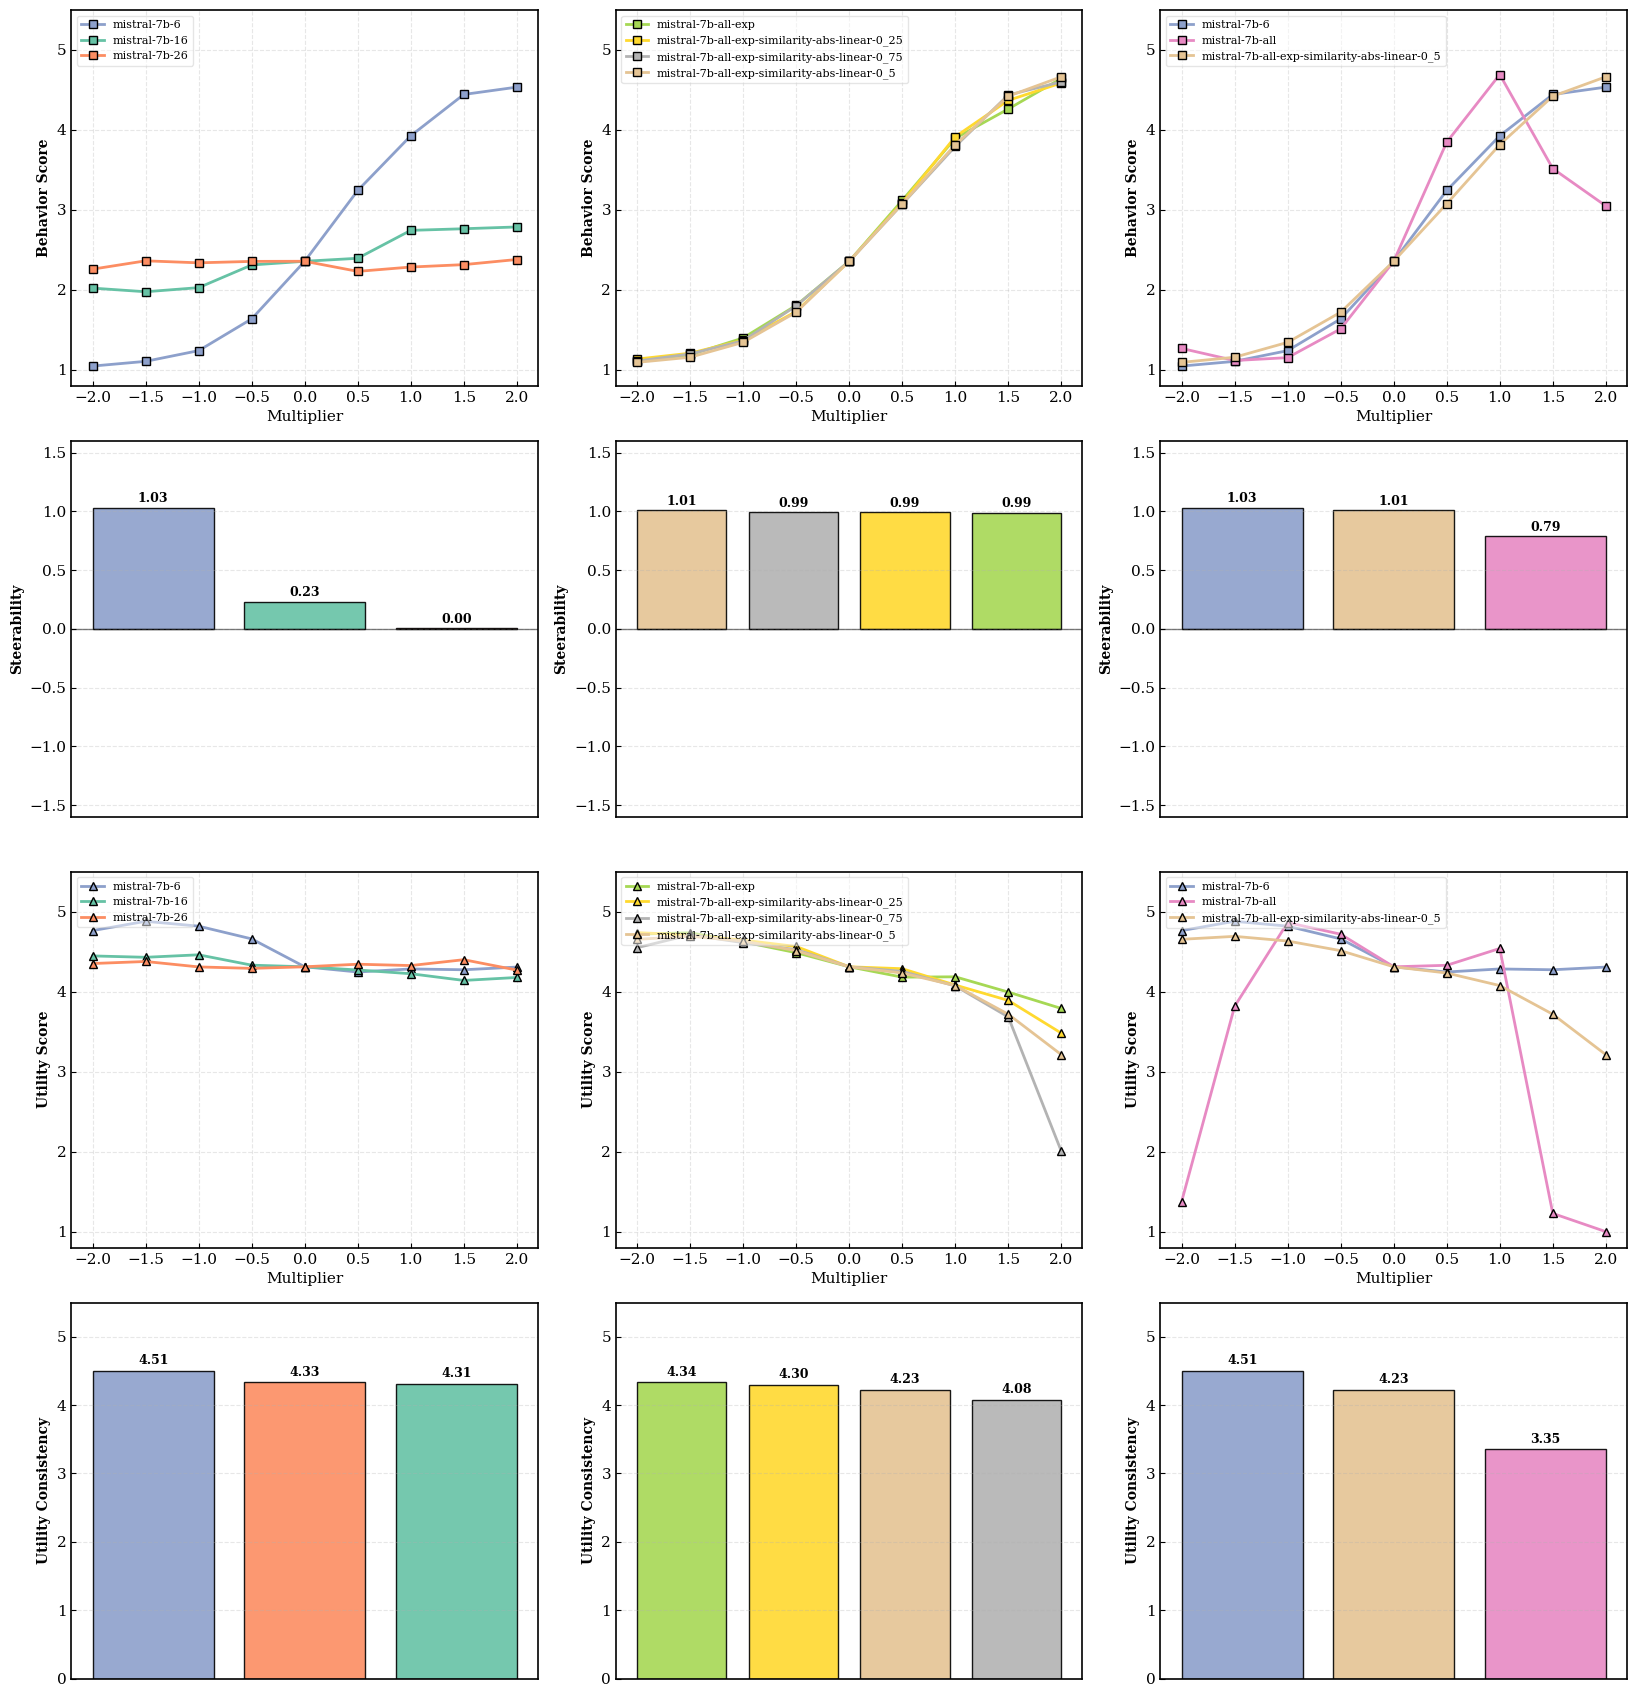

In [16]:
data_mistral = {
    "Single Layer Ablation": {
        "mistral-7b-6": {
            "behavior": {-2.0: 1.0483870967741935, -1.5: 1.1073446327683616, -1.0: 1.2413793103448276, -0.5: 1.6384180790960452, 0.0: 2.3585858585858586, 0.5: 3.243523316062176, 1.0: 3.9270833333333335, 1.5: 4.4438775510204085, 2.0: 4.535714285714286},
            "utility": {-2.0: 4.763819095477387, -1.5: 4.88, -1.0: 4.819095477386934, -0.5: 4.66, 0.0: 4.311224489795919, 0.5: 4.246153846153846, 1.0: 4.284263959390863, 1.5: 4.274111675126903, 2.0: 4.3076923076923075}
        },
        "mistral-7b-16": {
            "behavior": {-2.0: 2.0229885057471266, -1.5: 1.9774011299435028, -1.0: 2.0289017341040463, -0.5: 2.3121387283236996, 0.0: 2.3585858585858586, 0.5: 2.3959390862944163, 1.0: 2.7448979591836733, 1.5: 2.7653061224489797, 2.0: 2.7875647668393784},
            "utility": {-2.0: 4.447236180904523, -1.5: 4.43, -1.0: 4.461139896373057, -0.5: 4.331632653061225, 0.0: 4.311224489795919, 0.5: 4.271356783919598, 1.0: 4.224489795918367, 1.5: 4.14070351758794, 2.0: 4.177664974619289}
        },
        "mistral-7b-26": {
            "behavior": {-2.0: 2.260115606936416, -1.5: 2.3641618497109826, -1.0: 2.339080459770115, -0.5: 2.357142857142857, 0.0: 2.3585858585858586, 0.5: 2.2323232323232323, 1.0: 2.28643216080402, 1.5: 2.3165829145728645, 2.0: 2.3807106598984773},
            "utility": {-2.0: 4.3520408163265305, -1.5: 4.377551020408164, -1.0: 4.309644670050761, -0.5: 4.291457286432161, 0.0: 4.311224489795919, 0.5: 4.343434343434343, 1.0: 4.326633165829146, 1.5: 4.4, 2.0: 4.27}
        }
    },
    "k1 Ablation": {
        "mistral-7b-all-exp": {
            "behavior": {-2.0: 1.115606936416185, -1.5: 1.1890243902439024, -1.0: 1.4, -0.5: 1.8068181818181819, 0.0: 2.3585858585858586, 0.5: 3.1197916666666665, 1.0: 3.8958333333333335, 1.5: 4.262626262626263, 2.0: 4.644670050761421},
            "utility": {-2.0: 4.72, -1.5: 4.7360406091370555, -1.0: 4.623115577889447, -0.5: 4.4874371859296485, 0.0: 4.311224489795919, 0.5: 4.181818181818182, 1.0: 4.185929648241206, 1.5: 3.9949748743718594, 2.0: 3.7903225806451615}
        },
        "mistral-7b-all-exp-similarity-abs-linear-0_25": {
            "behavior": {-2.0: 1.136094674556213, -1.5: 1.2093023255813953, -1.0: 1.3714285714285714, -0.5: 1.7307692307692308, 0.0: 2.3585858585858586, 0.5: 3.0918367346938775, 1.0: 3.9157894736842107, 1.5: 4.37, 2.0: 4.5879396984924625},
            "utility": {-2.0: 4.738693467336684, -1.5: 4.708542713567839, -1.0: 4.644670050761421, -0.5: 4.565, 0.0: 4.311224489795919, 0.5: 4.287179487179487, 1.0: 4.082901554404145, 1.5: 3.890625, 2.0: 3.481865284974093}
        },
        "mistral-7b-all-exp-similarity-abs-linear-0_75": {
            "behavior": {-2.0: 1.1111111111111112, -1.5: 1.2, -1.0: 1.3652694610778444, -0.5: 1.8011363636363635, 0.0: 2.3585858585858586, 0.5: 3.0725388601036268, 1.0: 3.7948717948717947, 1.5: 4.437185929648241, 2.0: 4.601063829787234},
            "utility": {-2.0: 4.55, -1.5: 4.710659898477157, -1.0: 4.613065326633166, -0.5: 4.525510204081633, 0.0: 4.311224489795919, 0.5: 4.253807106598985, 1.0: 4.071428571428571, 1.5: 3.6844919786096257, 2.0: 2.0054054054054054}
        },
        "mistral-7b-all-exp-similarity-abs-linear-0_5": {
            "behavior": {-2.0: 1.0946745562130178, -1.5: 1.1588235294117648, -1.0: 1.345029239766082, -0.5: 1.7218934911242603, 0.0: 2.3585858585858586, 0.5: 3.077720207253886, 1.0: 3.816326530612245, 1.5: 4.422110552763819, 2.0: 4.664948453608248},
            "utility": {-2.0: 4.654822335025381, -1.5: 4.691919191919192, -1.0: 4.633165829145729, -0.5: 4.5126903553299496, 0.0: 4.311224489795919, 0.5: 4.233502538071066, 1.0: 4.076530612244898, 1.5: 3.717948717948718, 2.0: 3.2127659574468086}
        }
    },
    "Multi Layer Ablation": {
        "mistral-7b-6": {
            "behavior": {-2.0: 1.0483870967741935, -1.5: 1.1073446327683616, -1.0: 1.2413793103448276, -0.5: 1.6384180790960452, 0.0: 2.3585858585858586, 0.5: 3.243523316062176, 1.0: 3.9270833333333335, 1.5: 4.4438775510204085, 2.0: 4.535714285714286},
            "utility": {-2.0: 4.763819095477387, -1.5: 4.88, -1.0: 4.819095477386934, -0.5: 4.66, 0.0: 4.311224489795919, 0.5: 4.246153846153846, 1.0: 4.284263959390863, 1.5: 4.274111675126903, 2.0: 4.3076923076923075}
        },
        "mistral-7b-all": {
            "behavior": {-2.0: 1.2690058479532165, -1.5: 1.1176470588235294, -1.0: 1.1538461538461537, -0.5: 1.5138121546961325, 0.0: 2.3585858585858586, 0.5: 3.8477157360406093, 1.0: 4.693467336683417, 1.5: 3.517766497461929, 2.0: 3.0505050505050506},
            "utility": {-2.0: 1.3756345177664975, -1.5: 3.817258883248731, -1.0: 4.864321608040201, -0.5: 4.71859296482412, 0.0: 4.311224489795919, 0.5: 4.32994923857868, 1.0: 4.540404040404041, 1.5: 1.2279792746113989, 2.0: 1.0}
        },
        "mistral-7b-all-exp-similarity-abs-linear-0_5": {
            "behavior": {-2.0: 1.0946745562130178, -1.5: 1.1588235294117648, -1.0: 1.345029239766082, -0.5: 1.7218934911242603, 0.0: 2.3585858585858586, 0.5: 3.077720207253886, 1.0: 3.816326530612245, 1.5: 4.422110552763819, 2.0: 4.664948453608248},
            "utility": {-2.0: 4.654822335025381, -1.5: 4.691919191919192, -1.0: 4.633165829145729, -0.5: 4.5126903553299496, 0.0: 4.311224489795919, 0.5: 4.233502538071066, 1.0: 4.076530612244898, 1.5: 3.717948717948718, 2.0: 3.2127659574468086}
        }
    }
}
plot_bipo_data(data_mistral)